# Flight Final Descent Anomaly Detection and Classification
Contributors: Elan Wilkinson, Melissa Short, Nicholas Short
----


---

## Set Up Necessary Dependencies
### Install Required Libraries

In [137]:
import warnings
warnings.filterwarnings('ignore')

!pip install --disable-pip-version-check -q pip --upgrade > /dev/null
!pip install --disable-pip-version-check -q wrapt --upgrade > /dev/null

!pip install --disable-pip-version-check -q awscli boto3

!pip install --disable-pip-version-check -q sagemaker
!pip install --disable-pip-version-check -q smdebug
!pip install --disable-pip-version-check -q sagemaker-experiments

!pip install --disable-pip-version-check -q PyAthena

!pip install --disable-pip-version-check -q awswrangler

!conda install -y zip

!pip install --upgrade tensorflow

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done

# All requested packages already installed.



In [138]:
!pip install s3fs


  Using cached botocore-1.36.3-py3-none-any.whl.metadata (5.7 kB)
Using cached botocore-1.36.3-py3-none-any.whl (13.3 MB)
  Attempting uninstall: botocore
    Found existing installation: botocore 1.36.26
    Uninstalling botocore-1.36.26:
      Successfully uninstalled botocore-1.36.26
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
boto3 1.36.26 requires botocore<1.37.0,>=1.36.26, but you have botocore 1.36.3 which is incompatible.
awscli 1.37.26 requires botocore==1.36.26, but you have botocore 1.36.3 which is incompatible.


#### Import Necessary Libraries

In [139]:
import random
import pandas as pd
import pickle
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import os
from tensorflow.keras.utils import to_categorical
import numpy as np
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import boto3
import sagemaker
from pyathena import connect
from keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow as tf
import tarfile
from sklearn.metrics import classification_report

### Import Training Data from CSV

In [140]:
bucket_name = 'sagemaker-studio-747058696454-3dm5sm573t8'#'flight-final-approach-detection-and-classification'

#### Create DataFrame from CSV

In [141]:
#df = pd.read_csv(f"s3://{bucket_name}/train_data/training_flight_data.csv")
import pandas as pd
df = pd.read_csv("s3://sagemaker-studio-747058696454-3dm5sm573t8/train_csv/training_flight_data.csv")


INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].
INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].
INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].
INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].
INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].
INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].
INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sh

In [142]:
df.head()

,SampleID,TimeStep,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,...,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Label
0,0,0,81.261190,82.652336,-8.111792,1969.6174,155.57140,-2.109358,-0.692778,-4.952854,...,0.006664,70.74118,985.42550,-3.662262,0.785912,-0.390141,-1.081870,0.972379,12.625183,0.0
1,0,1,79.604095,81.015700,-7.644611,1955.6995,154.51205,-2.109358,-0.867216,-5.198349,...,0.007448,70.71775,985.52030,-3.665276,0.046774,-0.756234,-0.704820,0.770077,11.893839,0.0
2,0,2,81.302110,80.770200,-7.552573,1940.0267,153.32867,-2.109358,-1.424093,-4.830105,...,0.009604,70.70276,985.41650,-3.940319,0.804820,-1.325632,-0.240446,0.543937,12.559112,0.0
3,0,3,82.345470,83.900276,-8.395265,1924.5493,150.88818,-2.109358,-1.141912,-4.625526,...,0.009408,70.74159,984.81710,-4.275129,1.077102,-0.326884,-0.191627,1.062817,10.542998,0.0
4,0,4,81.874930,82.754620,-7.854284,1905.3670,150.69461,-2.109358,-0.724660,-4.400490,...,0.009408,70.57045,985.23065,-4.241483,1.654806,0.129545,-0.528425,0.867628,9.713539,0.0


#### Set Column Names

In [143]:
df.columns = ['sample_id', 'time_step', 'aileron_pos_lh_deg', 'aileron_pos_rh_deg', 'corrected_angle_of_attack_deg', 'baro_correct_alt_lsp_ft', 'computed_airspeed_lsp_knots',
    'selected_course_deg', 'drift_angle_deg', 'elevator_pos_left_deg', 'te_flap_pos_disc', 'glideslope_dev_perc', 'selected_heading_deg', 'localizer_dev_perc', 'core_speed_avg_perc',
    'total_pressure_lsp_millibar', 'pitch_angle_lsp_deg', 'roll_angle_lsp_deg', 'rudder_pos_deg', 'true_heading_lsp_deg', 'vertical_accel_g', 'wind_speed_knots', 'label']

#### Get Float Columns

In [144]:
float_columns = [col for col in df.columns if col not in ['sample_id', 'time_step', 'label'] and df[col].dtype == 'float64']


### Incorporate Arrival Airport into Data
#### Bring in data from CSV

In [145]:
sample_ids = df['sample_id'].unique()
flight_metadata_df = pd.read_csv(f"s3://{bucket_name}/flight_metadata/DASHlink_full_fourclass_raw_meta.csv")
train_flight_metadata_train = flight_metadata_df[flight_metadata_df['data_instance'].isin(sample_ids)]

INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].


#### Filter down to just arrival airport and associated sample ID

In [146]:
arrival_and_samp = train_flight_metadata_train.copy()
arrival_and_samp = arrival_and_samp[['data_instance', 'arrival_airport']]
arrival_and_samp.columns = ['sample_id', 'arrival_airport']
arrival_and_samp['arrival_airport_catenc'], arrival_airport_mapping = pd.factorize(arrival_and_samp['arrival_airport'])
arrival_and_samp.drop(columns=['arrival_airport'], inplace=True)
arrival_and_samp['arrival_airport_catenc'] = arrival_and_samp['arrival_airport_catenc'].astype(float)
arrival_and_samp.head()

,sample_id,arrival_airport_catenc
0,0,0.0
2,2,0.0
3,3,1.0
5,5,0.0
6,6,2.0


#### Balance Classes in Training Data

In [147]:
num_unique = (int)(len((df[df['label'] == 3]))/160)
rand_zeroes = df[df['label'] == 0]['sample_id'].unique()
unique_zeros = random.choices(rand_zeroes, k=num_unique)
rand_ones = df[df['label'] == 1]['sample_id'].unique()
unique_ones = random.choices(rand_ones, k=num_unique)
rand_twos = df[df['label'] == 2]['sample_id'].unique()
unique_twos = random.choices(rand_twos, k=num_unique)
sampleids_to_keep = df[df['label'] == 3]['sample_id'].unique().tolist()
sampleids_to_keep.extend(unique_ones)
sampleids_to_keep.extend(unique_twos)
sampleids_to_keep.extend(unique_zeros)

training_df = df[df['sample_id'].isin(sampleids_to_keep)]

#### Append Categorically Encoded Arrival

In [148]:
training_df = training_df.merge(arrival_and_samp, on='sample_id', how='left')

#### Data Scaling

In [149]:
float_columns = [col for col in training_df.columns if col not in ['sample_id', 'time_step', 'label'] and training_df[col].dtype == 'float64']

df_scaled = training_df.copy()
scalers = []

scalers_directory = os.path.join(os.getcwd(), 'scalers')
if not os.path.exists(scalers_directory):
    os.makedirs(scalers_directory)

for col in float_columns:
  new_scaler = MinMaxScaler()
  scaler_name = os.path.join(scalers_directory,f"{col}_scaler.pkl")
  df_scaled[col] = new_scaler.fit_transform(df_scaled[[col]])
  scalers.append(new_scaler)
  with open(scaler_name, 'wb') as scaler_file:
    pickle.dump(new_scaler, scaler_file)

train_x = df_scaled.copy()
train_x = train_x.drop(columns=['label','sample_id'])
train_y = df_scaled['label']

##### Open Scalers

In [150]:
scalers = []

for col in float_columns:
  scaler_name = os.path.join(scalers_directory,f"{col}_scaler.pkl")

  with open(scaler_name, 'rb') as file:
      loaded_scaler = pickle.load(file)
      #df_scaled[col] = loaded_scaler.transform(df_scaled[[col]])
      scalers.append(loaded_scaler)

### Import and Prepare Validation Data
---

In [151]:
valid_df = pd.read_csv(f"s3://{bucket_name}/valid_csv/valid_flight_data.csv")
valid_df.columns = ['sample_id', 'time_step', 'aileron_pos_lh_deg', 'aileron_pos_rh_deg', 'corrected_angle_of_attack_deg',
'baro_correct_alt_lsp_ft', 'computed_airspeed_lsp_knots',
    'selected_course_deg', 'drift_angle_deg', 'elevator_pos_left_deg', 'te_flap_pos_disc', 'glideslope_dev_perc', 'selected_heading_deg', 'localizer_dev_perc', 'core_speed_avg_perc',
    'total_pressure_lsp_millibar', 'pitch_angle_lsp_deg', 'roll_angle_lsp_deg', 'rudder_pos_deg', 'true_heading_lsp_deg', 'vertical_accel_g', 'wind_speed_knots', 'label']

INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].
INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].
INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].
INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].
INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].
INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].
INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sh

In [152]:
valid_ids = valid_df['sample_id'].unique()
print(valid_ids)
flight_metadata_valid = flight_metadata_df[flight_metadata_df['data_instance'].isin(valid_ids)]
flight_metadata_valid.head()
arrival_and_samp = flight_metadata_valid.copy()
arrival_and_samp = arrival_and_samp[['data_instance', 'arrival_airport']]
arrival_and_samp.columns = ['sample_id', 'arrival_airport']
arrival_and_samp
valid_df = valid_df.merge(arrival_and_samp, on='sample_id', how='left')
valid_df['arrival_airport_catenc'] = valid_df['arrival_airport'].map(dict(enumerate(arrival_airport_mapping)))
valid_df.tail()

[   15    20    21 ... 99806 99809 99810]


,sample_id,time_step,aileron_pos_lh_deg,aileron_pos_rh_deg,corrected_angle_of_attack_deg,baro_correct_alt_lsp_ft,computed_airspeed_lsp_knots,selected_course_deg,drift_angle_deg,elevator_pos_left_deg,...,total_pressure_lsp_millibar,pitch_angle_lsp_deg,roll_angle_lsp_deg,rudder_pos_deg,true_heading_lsp_deg,vertical_accel_g,wind_speed_knots,label,arrival_airport,arrival_airport_catenc
1629275,99810,155,83.73661,69.49784,1.817228,616.34467,125.377450,-145.0185,-0.701310,-1.822781,...,1004.52594,3.309562,1.056722,-0.471746,-151.14806,0.991589,1.355669,3.0,KDTW,NaN
1629276,99810,156,82.55005,74.89876,1.139800,614.71620,124.622140,-145.0185,-1.029845,-1.679573,...,1004.09440,3.003177,1.689748,-0.586573,-150.18675,1.009410,2.146087,3.0,KDTW,NaN
1629277,99810,157,79.89050,77.19005,1.652527,613.72650,123.039150,-145.0185,-1.113408,0.018440,...,1003.51263,3.108795,0.979927,-0.487490,-150.80489,0.973769,2.340231,3.0,KDTW,NaN
1629278,99810,158,78.21295,73.48715,1.715791,616.63040,121.915794,-145.0185,-1.802660,5.664848,...,1002.90576,2.889801,0.005120,-0.576744,-149.50856,1.035906,3.913119,3.0,KDTW,NaN
1629279,99810,159,73.46670,70.37753,0.894369,614.58470,119.480550,-145.0185,-1.632066,3.046223,...,1001.97240,2.361194,-0.899853,-0.491064,-150.44374,0.995308,3.952124,3.0,KDTW,NaN


In [153]:
arrival_airport_mapping_dict = {airport: idx for idx, airport in enumerate(arrival_airport_mapping)}
valid_df['arrival_airport_catenc'] = valid_df['arrival_airport'].map(arrival_airport_mapping_dict)
valid_df['arrival_airport_catenc'] = valid_df['arrival_airport_catenc'].astype(float)
valid_df.drop(columns=['arrival_airport'], inplace=True)
valid_df.head()

,sample_id,time_step,aileron_pos_lh_deg,aileron_pos_rh_deg,corrected_angle_of_attack_deg,baro_correct_alt_lsp_ft,computed_airspeed_lsp_knots,selected_course_deg,drift_angle_deg,elevator_pos_left_deg,...,core_speed_avg_perc,total_pressure_lsp_millibar,pitch_angle_lsp_deg,roll_angle_lsp_deg,rudder_pos_deg,true_heading_lsp_deg,vertical_accel_g,wind_speed_knots,label,arrival_airport_catenc
0,15,0,80.606540,81.54761,-5.420757,2468.7761,180.01007,34.98022,3.319528,-3.500336,...,61.523205,978.03235,-1.985861,-1.344085,-2.817326,24.699790,1.015660,14.561880,0.0,5.0
1,15,1,79.849594,80.42242,-5.116660,2453.4820,178.55055,34.98022,3.403981,-3.561710,...,61.480885,977.95966,-1.719461,-1.292599,1.381010,24.573366,1.040051,14.044608,0.0,5.0
2,15,2,81.506690,82.01814,-4.978041,2441.3076,179.56377,34.98022,3.030978,-3.459419,...,61.483383,978.70500,-1.735226,0.008662,-3.048076,24.782553,1.032340,14.027080,0.0,5.0
3,15,3,81.813560,82.79555,-5.357613,2426.1600,177.57582,34.98022,3.490517,-3.664001,...,61.506645,978.21350,-1.802503,1.149909,1.843847,24.539455,1.000205,13.811078,0.0,5.0
4,15,4,82.652336,83.10242,-6.084550,2411.2341,179.69500,34.98022,3.546878,-3.664001,...,61.506870,980.06050,-2.078131,0.974984,-2.606024,24.573948,0.967859,15.460607,0.0,5.0


In [154]:
valid_scaled = valid_df.copy()
for i in range (0,len(float_columns)):
  valid_scaled[float_columns[i]] = scalers[i].transform(valid_scaled[[float_columns[i]]])

In [155]:
valid_x = valid_scaled.copy()
valid_x = valid_x.drop(columns=['label','sample_id'])
valid_y = valid_scaled['label']

#### Need Categorical Y for LSTM

## Data Lake and Feature Store
---


In [156]:
session = boto3.session.Session()
region = session.region_name
sagemaker_session = sagemaker.Session()
bucket = 'flight-final-approach-detection-and-classification' # bucket name here

s3 = boto3.Session().client(service_name="s3", region_name=region)

print("Bucket name: {}".format(bucket))

Bucket name: flight-final-approach-detection-and-classification


In [157]:
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
account_id = boto3.client(service_name="sagemaker", region_name=region)

In [158]:
from IPython.core.display import display, HTML

display(
    HTML(
        '<b>Review <a target="blank" href="https://s3.console.aws.amazon.com/s3/buckets/flight-final-approach-detection-and-classification/?region={}&tab=overview">S3 Bucket</a></b>'.format(
            region, account_id, region
        )
    )
)

### Create Athena Database Scheme


In [159]:
database_name = "trainflightdata_db"
s3_staging_dir = "s3://{0}/athena/staging".format(bucket)
conn = connect(region_name=region, s3_staging_dir=s3_staging_dir)

statement = "CREATE DATABASE IF NOT EXISTS {}".format(database_name)
print(statement)

CREATE DATABASE IF NOT EXISTS trainflightdata_db


In [160]:
cursor = conn.cursor()
cursor.execute(statement)
print("Database created successfully")

ERROR:pyathena.common:Failed to execute query.
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/pyathena/common.py", line 586, in _execute
    query_id = retry_api_call(
               ^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/pyathena/util.py", line 84, in retry_api_call
    return retry(func, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/tenacity/__init__.py", line 475, in __call__
    do = self.iter(retry_state=retry_state)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/tenacity/__init__.py", line 376, in iter
    result = action(retry_state)
             ^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/tenacity/__init__.py", line 398, in <lambda>
    self._add_action_func(lambda rs: rs.outcome.result())
                                     ^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/concurrent/fu

DatabaseError: An error occurred (InvalidRequestException) when calling the StartQueryExecution operation: Unable to verify/create output bucket flight-final-approach-detection-and-classification

In [161]:
statement = "SHOW DATABASES"

df_show = pd.read_sql(statement, conn)
df_show.head(5)

ERROR:pyathena.common:Failed to execute query.
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/pyathena/common.py", line 586, in _execute
    query_id = retry_api_call(
               ^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/pyathena/util.py", line 84, in retry_api_call
    return retry(func, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/tenacity/__init__.py", line 475, in __call__
    do = self.iter(retry_state=retry_state)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/tenacity/__init__.py", line 376, in iter
    result = action(retry_state)
             ^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/tenacity/__init__.py", line 398, in <lambda>
    self._add_action_func(lambda rs: rs.outcome.result())
                                     ^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/concurrent/fu

DatabaseError: Execution failed on sql: SHOW DATABASES
An error occurred (InvalidRequestException) when calling the StartQueryExecution operation: Unable to verify/create output bucket flight-final-approach-detection-and-classification
unable to rollback

### Register CSV with Athena

#### Use to drop table if already created and needing to Recreate

In [ ]:
drop_statement = "DROP TABLE trainflightdata_db.flight_csv_data"
cursor = conn.cursor()
cursor.execute(drop_statement)
print("Table dropped successfully.")

#### Add Label Back to Data for Sake of Feature Store

In [26]:
df['label']=train_y
df.head()

,sample_id,time_step,aileron_pos_lh_deg,aileron_pos_rh_deg,corrected_angle_of_attack_deg,baro_correct_alt_lsp_ft,computed_airspeed_lsp_knots,selected_course_deg,drift_angle_deg,elevator_pos_left_deg,...,localizer_dev_perc,core_speed_avg_perc,total_pressure_lsp_millibar,pitch_angle_lsp_deg,roll_angle_lsp_deg,rudder_pos_deg,true_heading_lsp_deg,vertical_accel_g,wind_speed_knots,label
0,0,0,81.261190,82.652336,-8.111792,1969.6174,155.57140,-2.109358,-0.692778,-4.952854,...,0.006664,70.74118,985.42550,-3.662262,0.785912,-0.390141,-1.081870,0.972379,12.625183,0.0
1,0,1,79.604095,81.015700,-7.644611,1955.6995,154.51205,-2.109358,-0.867216,-5.198349,...,0.007448,70.71775,985.52030,-3.665276,0.046774,-0.756234,-0.704820,0.770077,11.893839,0.0
2,0,2,81.302110,80.770200,-7.552573,1940.0267,153.32867,-2.109358,-1.424093,-4.830105,...,0.009604,70.70276,985.41650,-3.940319,0.804820,-1.325632,-0.240446,0.543937,12.559112,0.0
3,0,3,82.345470,83.900276,-8.395265,1924.5493,150.88818,-2.109358,-1.141912,-4.625526,...,0.009408,70.74159,984.81710,-4.275129,1.077102,-0.326884,-0.191627,1.062817,10.542998,0.0
4,0,4,81.874930,82.754620,-7.854284,1905.3670,150.69461,-2.109358,-0.724660,-4.400490,...,0.009408,70.57045,985.23065,-4.241483,1.654806,0.129545,-0.528425,0.867628,9.713539,0.0


In [27]:
statement = """CREATE EXTERNAL TABLE IF NOT EXISTS trainflightdata_db.flight_csv_data (
        sample_id int,
        timestep int,
        aileron_pos_lh_deg float,
        aileron_pos_rh_deg float,
        corrected_angle_of_attack_deg float,
        baro_correct_alt_lsp_ft float,
        computed_airspeed_lsp_knots float,
        selected_course_deg float,
        drift_angle_deg float,
        elevator_pos_left_deg float,
        te_flap_pos_disc float,
        glideslope_dev_perc float,
        selected_heading_deg float,
        localizer_dev_perc float,
        core_speed_avg_perc float,
        total_pressure_lsp_millibar float,
        pitch_angle_lsp_deg float,
        roll_angle_lsp_deg float,
        rudder_pos_deg float,
        true_heading_lsp_deg float,
        vertical_accel_g float,
        wind_speed_knots float,
        label int
)
STORED AS TEXTFILE
LOCATION 's3://flight-final-approach-detection-and-classification/training_data/'
TBLPROPERTIES (
    'skip.header.line.count'='1',
    'field.delim'=',',
    'compressionType'='none'
)"""

In [28]:
cursor = conn.cursor()
cursor.execute(statement)

In [29]:
pd.read_sql(statement, conn)

""


In [12]:
statement = "SHOW TABLES IN {}".format(database_name)
cursor = conn.cursor()
cursor.execute(statement)

#### Example Query

In [13]:
table_name_csv = "flight_csv_data"

statement = """SELECT sample_id, aileron_pos_lh_deg, timestep, label FROM {}.{}
    LIMIT 10""".format(
    database_name, table_name_csv
)

print(statement)

df = pd.read_sql(statement, conn)
df.head(5)

SELECT sample_id, aileron_pos_lh_deg, timestep, label FROM trainflightdata_db.flight_csv_data
    LIMIT 10


,sample_id,aileron_pos_lh_deg,timestep,label
0,77952,86.252945,149,0
1,77952,83.613860,150,0
2,77952,79.972336,151,0
3,77952,84.493560,152,0
4,77952,84.002560,153,0


#### Retrieve Data from Feature Store

In [35]:
training_db_name = 'trainflightdata_db'

statement = """SELECT * FROM {}.{}""".format(
    training_db_name, table_name_csv
)

print(statement)

train_df = pd.read_sql(statement, conn)
train_df.head(5)

SELECT * FROM trainflightdata_db.flight_csv_data


,sample_id,timestep,aileron_pos_lh_deg,aileron_pos_rh_deg,corrected_angle_of_attack_deg,baro_correct_alt_lsp_ft,computed_airspeed_lsp_knots,selected_course_deg,drift_angle_deg,elevator_pos_left_deg,...,localizer_dev_perc,core_speed_avg_perc,total_pressure_lsp_millibar,pitch_angle_lsp_deg,roll_angle_lsp_deg,rudder_pos_deg,true_heading_lsp_deg,vertical_accel_g,wind_speed_knots,label
0,31192,41,84.04348,85.045920,-2.721564,1446.7379,117.38952,-2.109358,-2.512033,0.959507,...,0.005684,79.405550,995.26385,-0.726776,0.731944,-1.251886,1.945618,0.973880,17.091684,0
1,31192,42,84.14577,84.943634,-3.337031,1439.0569,117.19384,-2.109358,-2.356308,0.979965,...,0.005880,79.348010,995.46570,-1.229672,0.458460,-0.892383,1.948298,0.979566,16.445845,0
2,31192,43,84.12531,83.552490,-3.356537,1430.2373,117.26822,-2.109358,-2.466953,1.000423,...,0.005488,79.395590,995.83790,-1.437902,-0.065344,-1.169684,2.009811,0.960074,16.500046,0
3,31192,44,84.14577,85.373250,-3.347764,1421.2080,117.41075,-2.109358,-2.512803,1.266377,...,0.005684,79.415054,996.14970,-1.339278,-0.099866,-1.300986,2.039185,0.997298,16.214132,0
4,31192,45,84.24806,84.411730,-2.623558,1412.3934,117.65066,-2.109358,-2.516298,1.511875,...,0.004704,79.453940,996.59973,-0.856149,-0.423833,-0.906220,1.929643,1.004105,16.646630,0


#### Create Validation, Test, and Prod Feature Store

In [14]:
data_names = ['valid','test','prod']

for data_set_name in data_names:
    table_name = f'{data_set_name}flight_csv_data'

    statement = f"""CREATE EXTERNAL TABLE IF NOT EXISTS trainflightdata_db.{data_set_name}flight_csv_data (
            sample_id int,
            timestep int,
            aileron_pos_lh_deg float,
            aileron_pos_rh_deg float,
            corrected_angle_of_attack_deg float,
            baro_correct_alt_lsp_ft float,
            computed_airspeed_lsp_knots float,
            selected_course_deg float,
            drift_angle_deg float,
            elevator_pos_left_deg float,
            te_flap_pos_disc float,
            glideslope_dev_perc float,
            selected_heading_deg float,
            localizer_dev_perc float,
            core_speed_avg_perc float,
            total_pressure_lsp_millibar float,
            pitch_angle_lsp_deg float,
            roll_angle_lsp_deg float,
            rudder_pos_deg float,
            true_heading_lsp_deg float,
            vertical_accel_g float,
            wind_speed_knots float,
            label int
    )
    STORED AS TEXTFILE
    LOCATION 's3://flight-final-approach-detection-and-classification/valid_data/'
    TBLPROPERTIES (
        'skip.header.line.count'='1',
        'field.delim'=',',
        'compressionType'='none'
    )"""

    cursor = conn.cursor()
    cursor.execute(statement)
    
    pd.read_sql(statement, conn)

    statement = "SHOW TABLES IN {}".format(database_name)
    cursor = conn.cursor()
    cursor.execute(statement)

In [15]:
prod_table_name_csv = "prodflight_csv_data"

statement = """SELECT sample_id, aileron_pos_lh_deg, timestep, label FROM {}.{}
    LIMIT 10""".format(
    database_name, prod_table_name_csv
)

print(statement)

df = pd.read_sql(statement, conn)
df.head(5)


SELECT sample_id, aileron_pos_lh_deg, timestep, label FROM trainflightdata_db.prodflight_csv_data
    LIMIT 10


,sample_id,aileron_pos_lh_deg,timestep,label
0,61412,83.450195,118,0
1,61412,83.491120,119,0
2,61412,83.470660,120,0
3,61412,83.470660,121,0
4,61412,83.450195,122,0


#### Create Testing Feature Store

#### Create Production Feature

## Modeling
### LSTM Model

### Reshape Data for Modeling
---

In [18]:
def reshape_data(x_data,y_data):
  num_samples = len(x_data) // 160
  num_features = x_data.shape[1]
  y_data_ = []
  for i in range(0,len(y_data),160):
    y_data_.append(y_data[i])

  x_data = x_data.values.reshape((num_samples, 160, num_features))
  y_data = np.array(y_data_)
  return x_data,y_data

In [19]:
train_x, train_y = reshape_data(train_x,train_y)
valid_x, valid_y = reshape_data(valid_x,valid_y)

In [20]:
train_y = to_categorical(train_y)
valid_y = to_categorical(valid_y)

In [21]:
training_x_tensor = torch.tensor(train_x, dtype=torch.float32)
training_y_tensor = torch.tensor(train_y, dtype=torch.float32)

2025-02-20 22:55:05.269924: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,532 (88.02 KB)

 Trainable params: 22,532 (88.02 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/340
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.2914 - loss: 1.4301

2025-02-20 22:55:09.176523: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 143376640 exceeds 10% of free system memory.


23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 237ms/step - accuracy: 0.2917 - loss: 1.4289 - val_accuracy: 0.0511 - val_loss: nan
Epoch 2/340
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 212ms/step - accuracy: 0.3226 - loss: 1.3595 - val_accuracy: 0.2420 - val_loss: nan
Epoch 3/340
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 213ms/step - accuracy: 0.3049 - loss: 1.3534 - val_accuracy: 0.0551 - val_loss: nan
Epoch 4/340
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 212ms/step - accuracy: 0.3297 - loss: 1.3441 - val_accuracy: 0.0602 - val_loss: nan
Epoch 5/340
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 292ms/step - accuracy: 0.3097 - loss: 1.3392 - val_accuracy: 0.2969 - val_loss: nan
Epoch 6/340
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 213ms/step - accuracy: 0.3468 - loss: 1.3225 - val_accuracy: 0.5074 - val_loss: nan
Epoch 7/340
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 214ms/step - accuracy: 0.3446 - loss: 1.3353 - val_accuracy: 0.4064 - val_loss: nan
Epoch 8/340
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 213ms/step - accuracy: 0.3370 - loss: 1.3334 - val_accuracy: 0.2311 - val_loss: nan
Epoc

Text(0.5, 1.0, 'model loss')

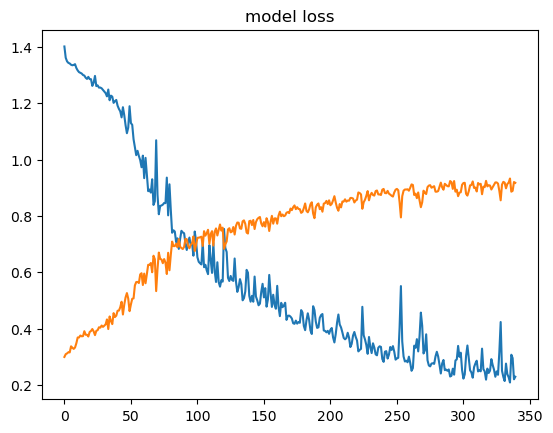

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow as tf

num_features = train_x.shape[2]

m_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

lstm_model = Sequential()
lstm_model.add(LSTM(64, input_shape=(160, num_features)))
lstm_model.add(Dense(4, activation='sigmoid'))
lstm_model.compile(optimizer=m_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
print(lstm_model.summary())
lstm_hist = lstm_model.fit(train_x, train_y, epochs=340, batch_size=64, validation_data=(valid_x, valid_y))

# plot hist
import matplotlib.pyplot as plt
plt.plot(lstm_hist.history['loss'])
plt.plot(lstm_hist.history['accuracy'])
plt.title('model loss')

Text(0.5, 1.0, 'model loss')

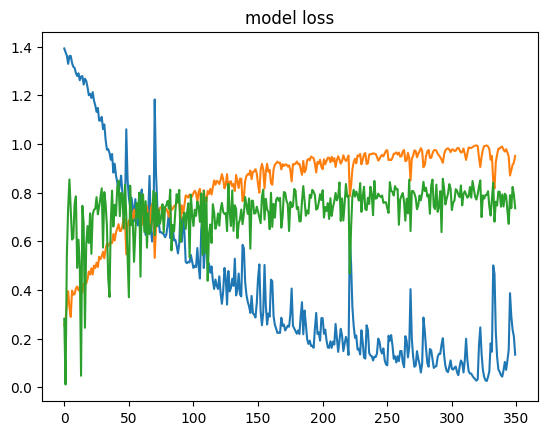

In [ ]:
# plot hist
import matplotlib.pyplot as plt
plt.plot(lstm_hist.history['loss'])
plt.plot(lstm_hist.history['accuracy'])
plt.plot(lstm_hist.history['val_accuracy'])
plt.title('model loss')

### Save Model

In [ ]:
model_dir = "/content/drive/MyDrive/USD (1)/FlightAnomalyClassification/LSTMmodel"
os.makedirs(model_dir, exist_ok=True)

model.export(model_dir)

tarball_name = "lstm_model.tar.gz"
with tarfile.open(tarball_name, "w:gz") as tar:
    tar.add(model_dir, arcname=os.path.basename(model_dir))

print(f"Model saved as {tarball_name}")

Saved artifact at '/content/drive/MyDrive/USD (1)/FlightAnomalyClassification/LSTMmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 22), dtype=tf.float32, name='keras_tensor_48')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  139820204656784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139820204658896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139820204659472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139820204659280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139820204659856: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model saved as lstm_model.tar.gz


### Classification Report

In [ ]:
valid_y_argmaxed = valid_y.argmax(axis=1)
print(classification_report(valid_y_argmaxed, preds.argmax(axis=1)))
print(preds)

              precision    recall  f1-score   support

           0       0.97      0.85      0.91      9146
           1       0.38      0.58      0.46       715
           2       0.19      0.69      0.29       225
           3       0.47      0.97      0.63        97

    accuracy                           0.83     10183
   macro avg       0.50      0.77      0.57     10183
weighted avg       0.91      0.83      0.86     10183

[[0.9692502  0.67852646 0.02187795 0.03043036]
 [0.9923308  0.02723334 0.00434992 0.88280094]
 [0.9900017  0.19605248 0.02492564 0.11360192]
 ...
 [0.0863151  0.5634494  0.00118054 0.9997788 ]
 [0.03979751 0.51264393 0.00385703 0.9998391 ]
 [0.93349063 0.04790827 0.00583803 0.98676866]]


### Random Forest Model

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [23]:
df_scaled.head()

,sample_id,time_step,aileron_pos_lh_deg,aileron_pos_rh_deg,corrected_angle_of_attack_deg,baro_correct_alt_lsp_ft,computed_airspeed_lsp_knots,selected_course_deg,drift_angle_deg,elevator_pos_left_deg,...,core_speed_avg_perc,total_pressure_lsp_millibar,pitch_angle_lsp_deg,roll_angle_lsp_deg,rudder_pos_deg,true_heading_lsp_deg,vertical_accel_g,wind_speed_knots,label,arrival_airport_catenc
0,142,0,0.458499,0.490801,0.259951,0.231723,0.288022,0.278404,0.517231,0.501118,...,0.512528,0.658916,0.468143,0.505780,0.519938,0.343707,0.879337,0.182556,0.0,14.0
1,142,1,0.478380,0.484336,0.207199,0.231283,0.272628,0.278404,0.494758,0.501118,...,0.510323,0.657062,0.430884,0.501850,0.509397,0.345584,0.871827,0.178423,0.0,14.0
2,142,2,0.491799,0.517404,0.283229,0.230732,0.261297,0.278404,0.500575,0.501118,...,0.512715,0.654941,0.409600,0.514017,0.517615,0.344641,0.874855,0.159641,0.0,14.0
3,142,3,0.472167,0.462954,0.273090,0.230020,0.261861,0.278404,0.533933,0.501366,...,0.509660,0.656280,0.367524,0.499669,0.538363,0.343151,0.879295,0.154721,0.0,14.0
4,142,4,0.474155,0.467926,0.233505,0.229384,0.262726,0.278404,0.535871,0.501118,...,0.511625,0.656804,0.339453,0.482828,0.516706,0.342203,0.870914,0.176675,0.0,14.0


In [37]:
train_x_avg = df_scaled.groupby("sample_id").mean().reset_index()
train_y_avg = train_x_avg['label']
train_x_avg = train_x_avg.drop(columns=["time_step","label"], errors="ignore")

In [38]:
rf_model = RandomForestClassifier(n_estimators=50,max_depth=10,random_state=33)
rf_model.fit(train_x_avg, train_y_avg)

RandomForestClassifier(max_depth=10, n_estimators=50, random_state=33)

In [39]:
with open("random_forest.pkl", "wb") as f:
    pickle.dump(rf_model, f)

In [40]:
!tar -czvf model.tar.gz random_forest.pkl

random_forest.pkl


In [48]:
!tar -czvf rf_model.tar.gz random_forest.pkl

random_forest.pkl


In [49]:
rf_s3_model_path = "s3://sagemaker-studio-747058696454-3dm5sm573t8/rf_model/rf_model.tar.gz"

In [50]:
from sagemaker.sklearn.model import SKLearnModel
from sagemaker import get_execution_role

role = get_execution_role()

from sagemaker import image_uris
image_uri = image_uris.retrieve(framework="sklearn", region=boto3.Session().region_name, version="1.2-1")

sklearn_model = SKLearnModel(
    model_data=rf_s3_model_path,
    role=role,
    entry_point="inference.py",
    image_uri=image_uri,
)

predictor = sklearn_model.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.large"
)


-----------------------------------------------*

UnexpectedStatusException: Error hosting endpoint sagemaker-scikit-learn-2025-02-21-01-37-28-565: Failed. Reason: The primary container for production variant AllTraffic did not pass the ping health check. Please check CloudWatch logs for this endpoint.. Try changing the instance type or reference the troubleshooting page https://docs.aws.amazon.com/sagemaker/latest/dg/async-inference-troubleshooting.html

## XGBoost

In [162]:
region = boto3.Session().region_name
training_image = sagemaker.image_uris.retrieve("xgboost", region, "1.0-1")

INFO:sagemaker.image_uris:Defaulting to only available Python version: py3
INFO:sagemaker.image_uris:Defaulting to only supported image scope: cpu.


In [163]:
from sagemaker.session import Session

boto_session = boto3.Session(region_name=region)
sagemaker_client = boto_session.client(service_name="sagemaker", region_name=region)
featurestore_runtime = boto_session.client(
    service_name="sagemaker-featurestore-runtime", region_name=region
)
region = boto3.Session().region_name
training_image = sagemaker.image_uris.retrieve("xgboost", region, "1.0-1")

from sagemaker.estimator import Estimator

INFO:sagemaker.image_uris:Defaulting to only available Python version: py3
INFO:sagemaker.image_uris:Defaulting to only supported image scope: cpu.


In [164]:
from sagemaker.sklearn.model import SKLearnModel
from sagemaker import get_execution_role

role = get_execution_role()

feature_store_session = Session(
    boto_session=boto_session,
    sagemaker_client=sagemaker_client,
    sagemaker_featurestore_runtime_client=featurestore_runtime,
)


training_output_path = "s3://" + bucket_name + "/" + "xgboost" + "/training_output"

training_model = Estimator(
    training_image,
    role,
    instance_count=1,
    instance_type="ml.m5.xlarge",
    volume_size=5,
    max_run=3600,
    input_mode="File",
    output_path=training_output_path,
    sagemaker_session=feature_store_session,
)

In [165]:
training_model.set_hyperparameters(
    objective="multi:softmax",
    num_class=4,
    num_round=100
)

In [166]:
xgb_train_df = training_df.copy()
xgb_train_df = training_df.groupby("sample_id").mean().reset_index()
xgb_train_df = xgb_train_df.drop(['label','sample_id','time_step'], axis=1)

xgb_train_df.insert(0, 'label', train_y)


xgb_train_df.head()

,label,aileron_pos_lh_deg,aileron_pos_rh_deg,corrected_angle_of_attack_deg,baro_correct_alt_lsp_ft,computed_airspeed_lsp_knots,selected_course_deg,drift_angle_deg,elevator_pos_left_deg,te_flap_pos_disc,...,localizer_dev_perc,core_speed_avg_perc,total_pressure_lsp_millibar,pitch_angle_lsp_deg,roll_angle_lsp_deg,rudder_pos_deg,true_heading_lsp_deg,vertical_accel_g,wind_speed_knots,arrival_airport_catenc
0,0.0,81.285103,82.666785,-4.472768,1405.909837,126.019784,34.98022,-2.900312,-2.253037,3500.16875,...,-0.000791,78.062519,988.871140,-1.865155,-0.350524,-0.479391,31.571251,0.805586,14.692571,5.0
1,0.0,80.892949,82.007143,-3.154666,766.566181,122.808552,86.92321,-0.335700,-2.608495,3700.44375,...,-0.000979,80.158816,1021.505127,-1.163472,-0.293563,-0.557466,76.040016,0.902617,20.855056,18.0
2,0.0,81.248151,81.119138,-4.357202,1505.603136,136.044527,-145.01850,-0.712475,-4.490631,3431.66250,...,-0.001844,73.450309,1000.359861,-1.761943,-0.310532,-0.287408,-150.706685,0.849138,4.933843,5.0
3,0.0,79.667259,82.173492,-4.752047,1292.975988,122.959536,172.87962,-3.649135,-3.614645,3699.91875,...,-0.003007,80.624711,991.611468,-2.184657,-0.161108,-1.182871,-163.108942,0.905447,9.748940,51.0
4,0.0,81.199435,82.076316,-4.672792,1644.600629,131.747464,-61.08354,-4.044215,-4.275694,3576.24375,...,-0.000448,76.651754,987.611868,-1.876851,-0.212032,-0.850495,-54.983528,0.902791,14.864746,9.0


In [167]:
s3_client = boto3.client("s3", region_name=region)

prefix = "sagemaker-flightfinaldescent"

In [168]:
xgb_train_df.to_csv("xgb_train_dataset.csv", header=False, index=False)
s3_client.upload_file("xgb_train_dataset.csv", bucket_name, prefix + "/training_input/dataset.csv")

In [169]:
print(bucket_name, prefix + "/training_input/dataset.csv")

sagemaker-studio-747058696454-3dm5sm573t8 sagemaker-flightfinaldescent/training_input/dataset.csv


In [170]:
dataset_uri_prefix = "s3://" + bucket_name + "/" + prefix + "/training_input/"

In [171]:
training_image = sagemaker.image_uris.retrieve("xgboost", region, "1.0-1")

INFO:sagemaker.image_uris:Defaulting to only available Python version: py3
INFO:sagemaker.image_uris:Defaulting to only supported image scope: cpu.


In [172]:
train_data = sagemaker.inputs.TrainingInput(
    dataset_uri_prefix,
    distribution="FullyReplicated",
    content_type="text/csv",
    s3_data_type="S3Prefix",
)
data_channels = {"train": train_data}

In [173]:
training_model.fit(inputs=data_channels, logs=True)

INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2025-02-23-23-46-10-902


2025-02-23 23:46:12 Starting - Starting the training job...
2025-02-23 23:46:26 Starting - Preparing the instances for training...
2025-02-23 23:46:52 Downloading - Downloading input data...
2025-02-23 23:47:17 Downloading - Downloading the training image...
2025-02-23 23:48:13 Training - Training image download completed. Training in progress.
2025-02-23 23:48:13 Uploading - Uploading generated training model.[2025-02-23 23:48:09.287 ip-10-0-198-118.ec2.internal:7 INFO utils.py:27] RULE_JOB_STOP_SIGNAL_FILENAME: None
INFO:sagemaker-containers:Imported framework sagemaker_xgboost_container.training
INFO:sagemaker-containers:Failed to parse hyperparameter objective value multi:softmax to Json.
Returning the value itself
INFO:sagemaker-containers:No GPUs detected (normal if no gpus installed)
INFO:sagemaker_xgboost_container.training:Running XGBoost Sagemaker in algorithm mode
INFO:root:Determined delimiter of CSV input is ','
INFO:root:Determined delimiter of CSV input is ','
INFO:root:

#### Hosting Model

In [63]:
### verified working, but does not allow for model monitoring
predictor = training_model.deploy(initial_instance_count=1, instance_type="ml.m5.xlarge")

INFO:sagemaker:Creating model with name: sagemaker-xgboost-2025-02-22-03-20-16-626
INFO:sagemaker:Creating endpoint-config with name sagemaker-xgboost-2025-02-22-03-20-16-626
INFO:sagemaker:Creating endpoint with name sagemaker-xgboost-2025-02-22-03-20-16-626


-----!

In [97]:
xgb_valid = valid_df.copy()
xgb_valid.head()
xgb_valid = xgb_valid.groupby("sample_id").mean().reset_index()
valid_labs = xgb_valid['label']
xgb_valid = xgb_valid.drop(['label','sample_id','time_step'], axis=1)
xgb_valid.insert(0, 'label', valid_labs)
xgb_valid = xgb_valid.sample(frac=1, random_state=33).reset_index(drop=True)

xgb_valid.head(35)

,label,aileron_pos_lh_deg,aileron_pos_rh_deg,corrected_angle_of_attack_deg,baro_correct_alt_lsp_ft,computed_airspeed_lsp_knots,selected_course_deg,drift_angle_deg,elevator_pos_left_deg,te_flap_pos_disc,...,localizer_dev_perc,core_speed_avg_perc,total_pressure_lsp_millibar,pitch_angle_lsp_deg,roll_angle_lsp_deg,rudder_pos_deg,true_heading_lsp_deg,vertical_accel_g,wind_speed_knots,arrival_airport_catenc
0,1.0,86.394872,86.590630,-7.975786,1491.857317,133.773006,-145.025092,-3.343900,-4.279786,3434.80000,...,-0.002947,76.580491,1003.590899,-3.933603,0.195756,-1.198918,-148.658128,0.897193,12.355561,5.0
1,0.0,85.832789,82.127461,-6.677885,1640.040229,140.813277,118.915170,-4.285656,-4.829211,3293.46875,...,0.034081,72.978342,980.449725,-2.995845,0.430555,-3.359413,126.112466,0.901355,13.009600,9.0
2,0.0,84.863847,82.963683,-4.160586,1619.224603,122.280001,-61.083540,-2.473708,-4.186830,3643.45000,...,-0.006504,75.382713,976.389539,-2.107812,-0.022213,-0.355622,-57.881321,0.845794,15.379795,9.0
3,0.0,83.687384,80.794878,-5.765788,1461.898829,138.251321,-58.095290,4.687723,-3.537928,3383.36250,...,-0.014353,75.130096,991.065083,-3.039929,-0.517799,-0.963516,-62.703696,0.920732,20.490281,29.0
4,0.0,81.661914,82.662055,-5.664768,1615.323926,123.942692,-61.083540,-4.104724,-5.067930,3680.39375,...,-0.001588,77.352329,979.043056,-2.472803,-0.107920,-0.894789,-55.105864,0.813338,14.682602,9.0
5,0.0,84.101531,79.690914,-9.235225,1639.039538,130.938242,118.915170,-2.845459,-4.265849,3441.56875,...,0.007170,78.024170,977.841943,-3.979588,0.052575,0.125551,123.655434,0.880142,15.869998,9.0
6,0.0,84.751584,82.372702,-4.698373,932.710525,130.370741,165.936330,-1.053037,-4.474904,3594.31875,...,-0.038031,71.695081,1009.311635,-2.212446,2.559603,-1.407515,161.118858,0.912532,15.607160,1.0
7,0.0,85.196289,84.392929,-5.133520,1077.262947,132.835302,177.889360,2.111242,-5.960922,3655.46250,...,-0.000853,77.906056,986.201666,-2.104946,0.119077,0.568185,176.261645,0.891720,25.643603,0.0
8,0.0,84.086571,80.831959,-3.892629,1727.845588,132.149897,50.976200,2.427915,-7.830399,3470.56250,...,-0.002129,74.892910,963.723807,-1.789419,-0.003865,-1.171219,51.810401,0.922729,18.317906,15.0
9,0.0,83.605296,83.554279,-3.627751,1088.218131,122.795393,157.938320,-5.370669,-3.975345,3700.14375,...,-0.001861,79.220664,994.294322,-2.001342,1.524278,-27.527844,160.178394,0.914128,17.205319,41.0


In [102]:
print(len(xgb_valid))

10183


In [98]:
xgb_valid.to_csv("xgb_valid_dataset.csv", header=False, index=False)
s3_client.upload_file("xgb_valid_dataset.csv", bucket_name, prefix + "/valid_input/dataset.csv")

In [17]:
xgb_valid_uri = "s3://sagemaker-studio-747058696454-3dm5sm573t8/sagemaker-flightfinaldescent/valid_input/dataset.csv"

In [75]:
valid_list = xgb_valid.to_numpy().tolist()

In [76]:
print(valid_list[0])

[0.48141295210183693, 0.49895469565522443, 0.42831270703060315, 0.12537096236889717, 0.3346708852914456, 0.6006876227897838, 0.6642102027285841, 0.46805194596573135, 0.9046464143426549, 0.5121487886217548, 0.5989226415633134, 0.4917185897379791, 0.6937803796099198, 0.7614742991947597, 0.5315112566924552, 0.4863997207839933, 0.48937383899132997, 0.5483746553970926, 0.8635964778197736, 0.16260264873382707, 0.05434782608695652]


In [77]:
valid_first =  ",".join(map(str, valid_list[0]))
print(valid_first)

0.48141295210183693,0.49895469565522443,0.42831270703060315,0.12537096236889717,0.3346708852914456,0.6006876227897838,0.6642102027285841,0.46805194596573135,0.9046464143426549,0.5121487886217548,0.5989226415633134,0.4917185897379791,0.6937803796099198,0.7614742991947597,0.5315112566924552,0.4863997207839933,0.48937383899132997,0.5483746553970926,0.8635964778197736,0.16260264873382707,0.05434782608695652


In [18]:
import json

In [22]:
#results = predictor.predict(",".join(inference_request), initial_args={"ContentType": "text/csv"})
results = predictor.predict(valid_first, initial_args={"ContentType": "text/csv"})
prediction = json.loads(results)
print(prediction)

NameError: name 'predictor' is not defined

In [19]:
from datetime import datetime, timedelta, timezone
from sagemaker.model_monitor import DataCaptureConfig

In [20]:


data_capture_prefix = f"{prefix}/datacapture"
s3_capture_upload_path = f"s3://{bucket_name}/{data_capture_prefix}"

endpoint_name = f"finaldescentclassification-xgb-quality-monitor-{datetime.utcnow():%Y-%m-%d-%H%M}"
print("EndpointName =", endpoint_name)

data_capture_config = DataCaptureConfig(
    enable_capture=True, sampling_percentage=100, destination_s3_uri=s3_capture_upload_path
)

training_model.deploy(
    initial_instance_count=1,
    instance_type="ml.m4.xlarge",
    endpoint_name=endpoint_name,
    data_capture_config=data_capture_config,
)

INFO:sagemaker:Creating model with name: sagemaker-xgboost-2025-02-23-16-11-50-696


EndpointName = finaldescentclassification-xgb-quality-monitor-2025-02-23-1611


INFO:sagemaker:Creating endpoint-config with name finaldescentclassification-xgb-quality-monitor-2025-02-23-1611
INFO:sagemaker:Creating endpoint with name finaldescentclassification-xgb-quality-monitor-2025-02-23-1611


------!

In [21]:
print(endpoint_name)

finaldescentclassification-xgb-quality-monitor-2025-02-23-1611




predictor = Predictor(
    endpoint_name=endpoint_name, sagemaker_session=session, serializer=CSVSerializer()
)

In [22]:
from sagemaker.predictor import Predictor
from sagemaker.serializers import CSVSerializer


In [23]:
session = Session()

predictor = Predictor(
    endpoint_name=endpoint_name, sagemaker_session=session, serializer=CSVSerializer()
)

In [24]:
from sagemaker import get_execution_role, session, Session, image_uris

In [25]:
session = Session()

### Need to Create Valid Dataset With Labels to Create Baseline
will be rerunning cells with label in first column again instead of removing

-done-

In [26]:
import boto3

s3 = boto3.client("s3")

In [27]:
validate_dataset = "s3://sagemaker-studio-747058696454-3dm5sm573t8/sagemaker-flightfinaldescent/valid_input/dataset.csv"

local_valid_dataset = "valid_dataset.csv"  # Save to the current directory

In [ ]:

file_key = "/".join(validate_dataset.split("/")[3:])

s3.download_file(bucket_name, file_key, local_valid_dataset)

print(f"✅ File downloaded to {local_valid_dataset}")


In [28]:
baseline_file_path = 'valid_baseline.csv'

In [29]:
import boto3
import json
import time

In [30]:
!pip show boto3
!pip install boto3 --upgrade


Name: boto3
Version: 1.36.3
Summary: The AWS SDK for Python
Home-page: https://github.com/boto/boto3
Author: Amazon Web Services
Author-email: 
License: Apache License 2.0
Location: /opt/conda/lib/python3.11/site-packages
Requires: botocore, jmespath, s3transfer
Required-by: amazon-q-developer-jupyterlab-ext, amazon-sagemaker-sql-editor, amazon-sagemaker-sql-execution, amazon_sagemaker_jupyter_ai_q_developer, autogluon.common, autogluon.core, autogluon.multimodal, aws-glue-sessions, awswrangler, langchain-aws, PyAthena, redshift_connector, sagemaker, sagemaker-experiments, sagemaker-kernel-wrapper, sagemaker-mlflow, sagemaker-studio-analytics-extension, sagemaker-studio-sparkmagic-lib, smdebug
  Using cached boto3-1.36.26-py3-none-any.whl.metadata (6.7 kB)
  Using cached botocore-1.36.26-py3-none-any.whl.metadata (5.7 kB)
Using cached boto3-1.36.26-py3-none-any.whl (139 kB)
Using cached botocore-1.36.26-py3-none-any.whl (13.4 MB)
  Attempting uninstall: botocore
    Found existing inst

In [31]:
import time
from time import sleep

baseline_file_path = 'valid_baseline.csv'
limit = 2000  # Need at least 200 samples to compute standard deviations
i = 0
with open(baseline_file_path, "w") as baseline_file:
    baseline_file.write("prediction,label\n")  # our header
with open(local_valid_dataset, "r") as f, open(baseline_file_path, "a") as baseline_file:
    for row in f:
        (label, input_cols) = row.split(",", 1)
        #input_cols = list(map(float, input_cols))  # Convert all values to float
        #print(f"Feature count: {len(input_cols)} - Values: {input_cols}")  # Debug output
    
        #probability = float(predictor.predict(input_cols))
        prediction = predictor.predict(input_cols)#"1" if probability > churn_cutoff else "0"
        baseline_file.write(f"{prediction},{label}\n")
        i += 1
        if i > limit:
            break
        print(".", end="", flush=True)
        sleep(0.5)
print()
print("Done!")

........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

In [32]:
!head valid_baseline.csv

prediction,label
b'0.0',1.0
b'0.0',0.0
b'0.0',0.0
b'0.0',0.0
b'0.0',0.0
b'0.0',0.0
b'0.0',0.0
b'0.0',0.0
b'0.0',0.0


In [33]:
baseline_prefix = prefix + "/baselining"
baseline_data_prefix = baseline_prefix + "/data"
baseline_results_prefix = baseline_prefix + "/results"

baseline_data_uri = f"s3://{bucket_name}/{baseline_data_prefix}"
baseline_results_uri = f"s3://{bucket_name}/{baseline_results_prefix}"
print(f"Baseline data uri: {baseline_data_uri}")
print(f"Baseline results uri: {baseline_results_uri}")

Baseline data uri: s3://sagemaker-studio-747058696454-3dm5sm573t8/sagemaker-flightfinaldescent/baselining/data
Baseline results uri: s3://sagemaker-studio-747058696454-3dm5sm573t8/sagemaker-flightfinaldescent/baselining/results


In [34]:
from sagemaker.s3 import S3Downloader, S3Uploader
baseline_dataset_uri = S3Uploader.upload(f"{baseline_file_path}", baseline_data_uri)
baseline_dataset_uri

's3://sagemaker-studio-747058696454-3dm5sm573t8/sagemaker-flightfinaldescent/baselining/data/valid_baseline.csv'

In [35]:
from sagemaker.model_monitor import ModelQualityMonitor
from sagemaker.model_monitor import EndpointInput
from sagemaker.model_monitor.dataset_format import DatasetFormat

In [36]:
flight_descent_model_quality_monitor = ModelQualityMonitor(
    role=role,
    instance_count=1,
    instance_type="ml.m5.xlarge",
    volume_size_in_gb=20,
    max_runtime_in_seconds=1800,
    sagemaker_session=session,
)

INFO:sagemaker.image_uris:Defaulting to the only supported framework/algorithm version: .
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.


In [37]:
baseline_job_name = f"xgb-flightdescent-model-baseline-job-{datetime.utcnow():%Y-%m-%d-%H%M%S}"


job = flight_descent_model_quality_monitor.suggest_baseline(
    job_name=baseline_job_name,
    baseline_dataset=baseline_dataset_uri,
    dataset_format=DatasetFormat.csv(header=True),
    output_s3_uri=baseline_results_uri,
    problem_type="MulticlassClassification",
    inference_attribute="prediction",
    ground_truth_attribute="label",
)
job.wait(logs=False)

INFO:sagemaker:Creating processing-job with name xgb-flightdescent-model-baseline-job-2025-02-23-163228


.............................................................!

In [38]:
baseline_job = flight_descent_model_quality_monitor.latest_baselining_job

In [39]:
qual_metrics = baseline_job.baseline_statistics().body_dict["multiclass_classification_metrics"]
pd.json_normalize(qual_metrics).T

INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].


,0
confusion_matrix.0.0.0.0,0.0
confusion_matrix.0.0.3.0,0.0
confusion_matrix.0.0.2.0,0.0
confusion_matrix.0.0.1.0,0.0
confusion_matrix.0.0.b'0.0',1802.0
confusion_matrix.3.0.0.0,0.0
confusion_matrix.3.0.3.0,0.0
confusion_matrix.3.0.2.0,0.0
confusion_matrix.3.0.1.0,0.0
confusion_matrix.3.0.b'0.0',22.0


In [40]:
pd.DataFrame(baseline_job.suggested_constraints().body_dict["multiclass_classification_constraints"]).T

INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].


,threshold,comparison_operator
accuracy,0.0,LessThanThreshold
weighted_recall,0.0,LessThanThreshold
weighted_precision,0.0,LessThanThreshold
weighted_f0_5,0.0,LessThanThreshold
weighted_f1,0.0,LessThanThreshold
weighted_f2,0.0,LessThanThreshold


In [41]:
def invoke_endpoint(ep_name, file_name):
    with open(file_name, "r") as f:
        i = 0
        for row in f:
            payload = row.rstrip("\n")
            response = session.sagemaker_runtime_client.invoke_endpoint(
                EndpointName=endpoint_name,
                ContentType="text/csv",
                Body=payload,
                InferenceId=str(i),  # unique ID per row
            )["Body"].read()
            i += 1
            sleep(1)


In [42]:
test_dataframe =pd.read_csv("s3://flight-final-approach-detection-and-classification-1/test_csv/test_flight_data.csv")
test_dataframe.columns = ['sample_id', 'time_step', 'aileron_pos_lh_deg', 'aileron_pos_rh_deg', 'corrected_angle_of_attack_deg',
'baro_correct_alt_lsp_ft', 'computed_airspeed_lsp_knots',
    'selected_course_deg', 'drift_angle_deg', 'elevator_pos_left_deg', 'te_flap_pos_disc', 'glideslope_dev_perc', 'selected_heading_deg', 'localizer_dev_perc', 'core_speed_avg_perc',
    'total_pressure_lsp_millibar', 'pitch_angle_lsp_deg', 'roll_angle_lsp_deg', 'rudder_pos_deg', 'true_heading_lsp_deg', 'vertical_accel_g', 'wind_speed_knots', 'label']
xgb_test_df = test_dataframe.groupby("sample_id").mean().reset_index()
test_labels = xgb_test_df['label']
xgb_test_df = xgb_test_df.drop(['label','sample_id','time_step'], axis=1)
xgb_test_df.insert(0, 'label', test_labels)
xgb_test_df = xgb_test_df.sample(frac=1, random_state=33).reset_index(drop=True)
xgb_test_df.head()

INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].
INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].
INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].
INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].
INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].
INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].
INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sh

,label,aileron_pos_lh_deg,aileron_pos_rh_deg,corrected_angle_of_attack_deg,baro_correct_alt_lsp_ft,computed_airspeed_lsp_knots,selected_course_deg,drift_angle_deg,elevator_pos_left_deg,te_flap_pos_disc,...,selected_heading_deg,localizer_dev_perc,core_speed_avg_perc,total_pressure_lsp_millibar,pitch_angle_lsp_deg,roll_angle_lsp_deg,rudder_pos_deg,true_heading_lsp_deg,vertical_accel_g,wind_speed_knots
0,0.0,82.632262,81.500168,-3.990590,1617.042522,124.255960,-61.083540,-4.966665,-0.510527,3582.56875,...,-60.028870,-0.009512,76.603479,983.448835,-1.806956,0.278362,-0.693925,-53.717973,0.839358,11.407469
1,0.0,82.765367,82.058544,-5.724190,1119.717950,128.883333,-2.109358,3.602016,-7.461772,3464.80625,...,-2.109358,-0.000834,77.872393,993.371130,-2.847690,-0.065914,1.408816,-4.984588,0.911786,9.770285
2,0.0,84.253431,83.946689,-6.055260,1759.334870,133.763993,-60.919306,1.142080,-3.554933,3524.78750,...,149.940340,0.002570,73.170995,991.468348,-3.322105,-0.820952,-0.568440,120.219044,0.887073,3.972784
3,0.0,82.387150,80.412698,-5.092207,908.403863,128.659199,165.936330,-1.856139,-8.927971,3591.21875,...,160.926590,-0.002155,80.225785,1012.778854,-2.297138,1.829263,-1.545778,165.543373,0.885454,4.309859
4,1.0,82.083860,81.057380,-7.586677,1633.046532,145.789490,-86.044310,-2.371823,-7.576976,3277.58125,...,-86.044310,0.000902,70.219877,992.720708,-3.604135,0.305766,-0.810969,-88.994774,0.872373,8.616058


In [133]:
xgb_test_df.to_csv("xgb_test_dataset.csv", header=False, index=False)
s3_client.upload_file("xgb_test_dataset.csv", bucket_name, prefix + "/valid_input/test_dataset.csv")

In [134]:
xgb_test_input_only = xgb_test_df.drop(['label'], axis=1)
xgb_test_df.to_csv("xgb_test_input_only_dataset.csv", header=False, index=False)
s3_client.upload_file("xgb_test_input_only_dataset.csv", bucket_name, prefix + "/valid_input/test_input_only_dataset.csv")

In [136]:
xgb_valid_input_only = xgb_valid.drop(['label'], axis=1)
xgb_valid_input_only.to_csv("xgb_valid_input_only_dataset.csv", header=False, index=False)
s3_client.upload_file("xgb_valid_input_only_dataset.csv", bucket_name, prefix + "/valid_input/valid_input_only_dataset.csv")

In [43]:
from threading import Thread

def invoke_endpoint_forever():
    while True:
        try:
            invoke_endpoint(endpoint_name, "xgb_valid_input_only_dataset.csv")
        except session.sagemaker_runtime_client.exceptions.ValidationError:
            pass

thread = Thread(target=invoke_endpoint_forever)
thread.start()

### View Captured Data

In [44]:
print("Waiting for captures to show up", end="")
for _ in range(120):
    capture_files = sorted(S3Downloader.list(f"{s3_capture_upload_path}/{endpoint_name}"))
    if capture_files:
        capture_file = S3Downloader.read_file(capture_files[-1]).split("\n")
        capture_record = json.loads(capture_file[0])
        if "inferenceId" in capture_record["eventMetadata"]:
            break
    print(".", end="", flush=True)
    sleep(1)
print()
print("Found Capture Files:")
print("\n ".join(capture_files[-3:]))

Waiting for captures to show up

INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].


.

INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].


.

...

.

INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].


.

INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].



Found Capture Files:
s3://sagemaker-studio-747058696454-3dm5sm573t8/sagemaker-flightfinaldescent/datacapture/finaldescentclassification-xgb-quality-monitor-2025-02-23-1611/AllTraffic/2025/02/23/16/30-30-001-efd0c6c1-07c1-4c6f-ba36-2a22516f5d49.jsonl
 s3://sagemaker-studio-747058696454-3dm5sm573t8/sagemaker-flightfinaldescent/datacapture/finaldescentclassification-xgb-quality-monitor-2025-02-23-1611/AllTraffic/2025/02/23/16/31-30-233-f307bcff-a764-439e-95df-2f1d1072b3f2.jsonl
 s3://sagemaker-studio-747058696454-3dm5sm573t8/sagemaker-flightfinaldescent/datacapture/finaldescentclassification-xgb-quality-monitor-2025-02-23-1611/AllTraffic/2025/02/23/16/37-53-050-22ea3391-eac6-440b-9528-efab1520a829.jsonl


#### View File Contents

In [45]:
print("\n".join(capture_file[-3:-1]))

{"captureData":{"endpointInput":{"observedContentType":"text/csv","mode":"INPUT","data":"85.3824572125,83.04219014374999,-4.3289340894125,1633.3787981875,129.44585283125,-61.08353999999999,-4.7264979286874995,-8.1211588575,3516.35625,-0.001126125172125007,-61.08353999999999,-0.0030588150597499982,74.913381775,982.8873600000001,-2.223774849321688,-0.16337338601875,-0.51493752365,-54.039961149999996,0.85606905225,11.125886531875,9.0","encoding":"CSV"},"endpointOutput":{"observedContentType":"text/csv; charset=utf-8","mode":"OUTPUT","data":"0.0","encoding":"CSV"}},"eventMetadata":{"eventId":"c4b883e8-63e4-4987-8cef-31b7d284daa3","inferenceId":"58","inferenceTime":"2025-02-23T16:38:51Z"},"eventVersion":"0"}
{"captureData":{"endpointInput":{"observedContentType":"text/csv","mode":"INPUT","data":"81.45592801875,82.479850375,-6.368016666875,1438.165049625,118.8589984375,-145.0185,8.379605877500001,-1.632776448125,3601.06875,-0.007356375434500004,-145.0185,0.00034790544199998964,78.25772313125

#### JSON Version

In [46]:
print(json.dumps(capture_record, indent=2))

{
  "captureData": {
    "endpointInput": {
      "observedContentType": "text/csv",
      "mode": "INPUT",
      "data": "86.3948721125,86.59062989374999,-7.975786190625,1491.8573174375001,133.7730057125,-145.02509174999997,-3.343900275625,-4.27978571425,3434.8,-0.004204689723625003,-147.03998,-0.0029473392493749996,76.58049063749999,1003.5908985624999,-3.9336033035,0.19575609782125,-1.1989183659406248,-148.6581284375,0.89719263164375,12.355561499375,5.0",
      "encoding": "CSV"
    },
    "endpointOutput": {
      "observedContentType": "text/csv; charset=utf-8",
      "mode": "OUTPUT",
      "data": "0.0",
      "encoding": "CSV"
    }
  },
  "eventMetadata": {
    "eventId": "1a5cc270-622c-452a-a219-7f61e70a815f",
    "inferenceId": "0",
    "inferenceTime": "2025-02-23T16:37:53Z"
  },
  "eventVersion": "0"
}


### Ground Truth

In [ ]:
"data":"0.0","encoding":"CSV"}},"eventMetadata":{"eventId":"c4b883e8-63e4-4987-8cef-31b7d284daa3","inferenceId":"58","inferenceTime":"2025-02-23T16:38:51Z"},"eventVersion":"0"

In [75]:
import random


def ground_truth_with_id(inference_id):
    random.seed(inference_id)  # to get consistent results
    rand = random.random()
    return {
        "groundTruthData": {
            "data": "0" if rand < 0.88 else "1" if rand < 0.94 else "2" if rand < 0.98 else "3",  # randomly generate positive labels 70% of the time
            "encoding": "CSV",
        },
        "eventMetadata": {
            "eventId": str(inference_id),
        },
        "eventVersion": "0",
        "data":"0.0","encoding":"CSV"}},"eventMetadata":{"eventId":"c4b883e8-63e4-4987-8cef-31b7d284daa3","inferenceId":"58","inferenceTime":"2025-02-23T16:38:51Z"},"eventVersion":"0"
    }


def upload_ground_truth(records, upload_time):
    fake_records = [json.dumps(r) for r in records]
    data_to_upload = "\n".join(fake_records)
    target_s3_uri = f"{ground_truth_upload_path}/{upload_time:%Y/%m/%d/%H/%M%S}.jsonl"
    print(f"Uploading {len(fake_records)} records to", target_s3_uri)
    S3Uploader.upload_string_as_file_body(data_to_upload, target_s3_uri)

In [76]:
NUM_GROUND_TRUTH_RECORDS = 334  # 334 are the number of rows in data we're sending for inference


def generate_fake_ground_truth_forever():
    j = 0
    while True:
        fake_records = [ground_truth_with_id(i) for i in range(NUM_GROUND_TRUTH_RECORDS)]
        upload_ground_truth(fake_records, datetime.utcnow())
        j = (j + 1) % 5
        sleep(60 * 60)  # do this once an hour


gt_thread = Thread(target=generate_fake_ground_truth_forever)
gt_thread.start()

Uploading 334 records to s3://sagemaker-studio-747058696454-3dm5sm573t8/ground-truth/2025/02/23/18/2345.jsonl
Uploading 334 records to s3://sagemaker-studio-747058696454-3dm5sm573t8/ground-truth/2025/02/23/19/2345.jsonl


In [94]:
test_df.head()

,0.0,82.632262475,81.50016814375,-3.9905903243750003,1617.042522125,124.25595995625,-61.08353999999999,-4.9666646880625,-0.51052708998125,3582.56875,...,-0.009512109995624999,76.60347920625,983.4488349999999,-1.8069556236250002,0.27836244364999996,-0.6939249357749999,-53.717973425000004,0.8393575284875,11.40746917,groundTruthMetadata.eventId
0,0.0,82.765367,82.058544,-5.724190,1119.717950,128.883333,-2.109358,3.602016,-7.461772,3464.80625,...,-0.000834,77.872393,993.371130,-2.847690,-0.065914,1.408816,-4.984588,0.911786,9.770285,0
1,0.0,84.253431,83.946689,-6.055260,1759.334870,133.763993,-60.919306,1.142080,-3.554933,3524.78750,...,0.002570,73.170995,991.468348,-3.322105,-0.820952,-0.568440,120.219044,0.887073,3.972784,1
2,0.0,82.387150,80.412698,-5.092207,908.403863,128.659199,165.936330,-1.856139,-8.927971,3591.21875,...,-0.002155,80.225785,1012.778854,-2.297138,1.829263,-1.545778,165.543373,0.885454,4.309859,2
3,1.0,82.083860,81.057380,-7.586677,1633.046532,145.789490,-86.044310,-2.371823,-7.576976,3277.58125,...,0.000902,70.219877,992.720708,-3.604135,0.305766,-0.810969,-88.994774,0.872373,8.616058,3
4,0.0,83.821640,82.449036,-5.633174,2100.359176,122.150043,-4.869109,0.873929,-3.528466,3558.10000,...,0.131169,78.839574,968.582641,-2.760112,3.523263,-0.261343,-22.307368,0.883960,5.572712,4


In [123]:
test_df = pd.read_csv("xgb_test_dataset.csv")
i = 0

#"data":"0.0","encoding":"CSV"}},"eventMetadata":{"eventId":"c4b883e8-63e4-4987-8cef-31b7d284daa3","inferenceId":"58","inferenceTime":"2025-02-23T16:38:51Z"},"eventVersion":"0"

def load_ground_truth():
    records = []
    i = 0
    for _, row in test_df.iterrows():
        record = {
        "groundTruthData": {
            "data": str(row.iloc[0]),  # First column is the label
            "encoding": "CSV"
        },
        "groundTruthMetadata": {  # ✅ Corrected to match inference data
            "eventId": str(i)  # ✅ Use real eventId, not index
        },
        "eventVersion": "0"
        }
        records.append(record)
        i = i + 1
    return records

ground_truth_upload_path = f"s3://{bucket_name}/ground-truth"

def upload_ground_truth(records, upload_time):
    formatted_records = [json.dumps(r) for r in records]  # Convert to JSONL format
    data_to_upload = "\n".join(formatted_records)  # JSON lines format
    target_s3_uri = f"{ground_truth_upload_path}/{upload_time:%Y/%m/%d/%H/%M%S}.jsonl"

    print(f"Uploading {len(formatted_records)} records to {target_s3_uri}")
    S3Uploader.upload_string_as_file_body(data_to_upload, target_s3_uri)

def upload_ground_truth_forever():
    while True:
        records = load_ground_truth()
        upload_ground_truth(records, datetime.utcnow())
        sleep(60 * 60)

gt_thread = Thread(target=upload_ground_truth_forever)
gt_thread.start()


Uploading 9942 records to s3://sagemaker-studio-747058696454-3dm5sm573t8/ground-truth/2025/02/23/21/1750.jsonl


### Create Monitoring Schedule

In [124]:
flightdescent_monitor_schedule_name = (
    f"xgb-flightdescent-monitoring-schedule-{datetime.utcnow():%Y-%m-%d-%H%M}"
)

In [125]:
endpointInput = EndpointInput(
    endpoint_name=predictor.endpoint_name,
    probability_attribute="0",
    probability_threshold_attribute=0.5,
    destination="/opt/ml/processing/input_data",
    inference_attribute="prediction"
)

### Schedule to Execute Every Hour

In [126]:
flight_descent_model_quality_monitor.delete_monitoring_schedule()

INFO:sagemaker:Deleting Monitoring Schedule with name: xgb-flightdescent-monitoring-schedule-2025-02-23-2031
INFO:sagemaker.model_monitor.model_monitoring:Deleting Model Quality Job Definition with name: model-quality-job-definition-2025-02-23-20-31-52-120


In [127]:
from sagemaker.model_monitor import CronExpressionGenerator

response = flight_descent_model_quality_monitor.create_monitoring_schedule(
    monitor_schedule_name=flightdescent_monitor_schedule_name,
    endpoint_input=endpointInput,
    output_s3_uri=baseline_results_uri,
    problem_type="MulticlassClassification",
    ground_truth_input=ground_truth_upload_path,
    constraints=baseline_job.suggested_constraints(),
    schedule_cron_expression=CronExpressionGenerator.hourly(),
    enable_cloudwatch_metrics=True,
)


INFO:botocore.httpchecksum:Skipping checksum validation. Response did not contain one of the following algorithms: ['crc32', 'sha1', 'sha256'].
INFO:sagemaker.model_monitor.model_monitoring:Creating Monitoring Schedule with name: xgb-flightdescent-monitoring-schedule-2025-02-23-2118


In [128]:
print(ground_truth_upload_path)

s3://sagemaker-studio-747058696454-3dm5sm573t8/ground-truth


In [129]:
flight_descent_model_quality_monitor.describe_schedule()

{'MonitoringScheduleArn': 'arn:aws:sagemaker:us-east-1:747058696454:monitoring-schedule/xgb-flightdescent-monitoring-schedule-2025-02-23-2118',
 'MonitoringScheduleName': 'xgb-flightdescent-monitoring-schedule-2025-02-23-2118',
 'MonitoringScheduleStatus': 'Pending',
 'MonitoringType': 'ModelQuality',
 'CreationTime': datetime.datetime(2025, 2, 23, 21, 18, 20, 235000, tzinfo=tzlocal()),
 'LastModifiedTime': datetime.datetime(2025, 2, 23, 21, 18, 20, 305000, tzinfo=tzlocal()),
 'MonitoringScheduleConfig': {'ScheduleConfig': {'ScheduleExpression': 'cron(0 * ? * * *)'},
  'MonitoringJobDefinitionName': 'model-quality-job-definition-2025-02-23-21-18-19-613',
  'MonitoringType': 'ModelQuality'},
 'EndpointName': 'finaldescentclassification-xgb-quality-monitor-2025-02-23-1611',
 'ResponseMetadata': {'RequestId': 'f35b8386-a253-42c3-923b-a93ff6337a09',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': 'f35b8386-a253-42c3-923b-a93ff6337a09',
   'content-type': 'application/x-amz-j

### Monitoring Schedule Executions

In [130]:
executions = flight_descent_model_quality_monitor.list_executions()
executions

[]

In [131]:
print("Waiting for first execution", end="")
while True:
    execution = flight_descent_model_quality_monitor.describe_schedule().get(
        "LastMonitoringExecutionSummary"
    )
    if execution:
        break
    print(".", end="", flush=True)
    sleep(10)
print()
print("Execution found!")

Waiting for first execution......................................................................................................................................................................................................................................................................
Execution found!


In [132]:
while not executions:
    executions = flight_descent_model_quality_monitor.list_executions()
    print(".", end="", flush=True)
    sleep(10)
latest_execution = executions[-1]
latest_execution.describe()

...................

{'ProcessingInputs': [{'InputName': 'groundtruth_input_1',
   'AppManaged': False,
   'S3Input': {'S3Uri': 's3://sagemaker-studio-747058696454-3dm5sm573t8/ground-truth/2025/02/23/21',
    'LocalPath': '/opt/ml/processing/groundtruth/2025/02/23/21',
    'S3DataType': 'S3Prefix',
    'S3InputMode': 'File',
    'S3DataDistributionType': 'FullyReplicated',
    'S3CompressionType': 'None'}},
  {'InputName': 'endpoint_input_1',
   'AppManaged': False,
   'S3Input': {'S3Uri': 's3://sagemaker-studio-747058696454-3dm5sm573t8/sagemaker-flightfinaldescent/datacapture/finaldescentclassification-xgb-quality-monitor-2025-02-23-1611/AllTraffic/2025/02/23/21',
    'LocalPath': '/opt/ml/processing/input_data/finaldescentclassification-xgb-quality-monitor-2025-02-23-1611/AllTraffic/2025/02/23/21',
    'S3DataType': 'S3Prefix',
    'S3InputMode': 'File',
    'S3DataDistributionType': 'FullyReplicated',
    'S3CompressionType': 'None'}}],
 'ProcessingOutputConfig': {'Outputs': [{'OutputName': 'result',
  

#### Inspect a Specific Execution

In [133]:
status = execution["MonitoringExecutionStatus"]

while status in ["Pending", "InProgress"]:
    print("Waiting for execution to finish", end="")
    latest_execution.wait(logs=False)
    latest_job = latest_execution.describe()
    print()
    print(f"{latest_job['ProcessingJobName']} job status:", latest_job["ProcessingJobStatus"])
    print(
        f"{latest_job['ProcessingJobName']} job exit message, if any:",
        latest_job.get("ExitMessage"),
    )
    print(
        f"{latest_job['ProcessingJobName']} job failure reason, if any:",
        latest_job.get("FailureReason"),
    )
    sleep(
        30
    )  # model quality executions consist of two Processing jobs, wait for second job to start
    latest_execution = flight_descent_model_quality_monitor.list_executions()[-1]
    execution = flight_descent_model_quality_monitor.describe_schedule()["LastMonitoringExecutionSummary"]
    status = execution["MonitoringExecutionStatus"]

print("Execution status is:", status)

if status != "Completed":
    print(execution)
    print(
        "====STOP==== \n No completed executions to inspect further. Please wait till an execution completes or investigate previously reported failures."
    )

Waiting for execution to finish...........................*

UnexpectedStatusException: Error for Processing job groundtruth-merge-202502232200-f4c3460024759940dd859e28: Failed. Reason: AlgorithmError: Error: Errors occurred when merging your data. Please check CloudWatch logs for more details., exit code: 255

In [134]:
import boto3

# Initialize CloudWatch logs client
logs_client = boto3.client("logs")

# Define the log group for SageMaker Processing jobs
log_group = "/aws/sagemaker/ProcessingJobs"

# Get the failed job name from the error message
processing_job_name = "groundtruth-merge-202502232200-f4c3460024759940dd859e28"

# Get log streams related to the failed job
log_streams = logs_client.describe_log_streams(
    logGroupName=log_group, orderBy="LastEventTime", descending=True
)

# Find the relevant log stream
log_stream_name = None
for stream in log_streams["logStreams"]:
    if processing_job_name in stream["logStreamName"]:
        log_stream_name = stream["logStreamName"]
        break

if log_stream_name:
    # Fetch and print the latest logs from CloudWatch
    log_events = logs_client.get_log_events(
        logGroupName=log_group, logStreamName=log_stream_name, limit=50
    )

    print("\n===== CloudWatch Logs =====")
    for event in log_events["events"]:
        print(event["message"])
else:
    print("No logs found for this job.")



===== CloudWatch Logs =====
2025-02-23 22:07:31 INFO  SchedulerExtensionServices:54 - Stopping SchedulerExtensionServices
(serviceOption=None,
 services=List(),
 started=false)
2025-02-23 22:07:31 INFO  YarnClientSchedulerBackend:54 - Stopped
2025-02-23 22:07:31 INFO  MapOutputTrackerMasterEndpoint:54 - MapOutputTrackerMasterEndpoint stopped!
2025-02-23 22:07:31 INFO  MemoryStore:54 - MemoryStore cleared
2025-02-23 22:07:31 INFO  BlockManager:54 - BlockManager stopped
2025-02-23 22:07:31 INFO  BlockManagerMaster:54 - BlockManagerMaster stopped
2025-02-23 22:07:31 INFO  OutputCommitCoordinator$OutputCommitCoordinatorEndpoint:54 - OutputCommitCoordinator stopped!
2025-02-23 22:07:31 INFO  SparkContext:54 - Successfully stopped SparkContext
2025-02-23 22:07:31 ERROR Main:74 - Reference 'groundTruthMetadata.eventId' is ambiguous, could be: groundTruthMetadata, groundTruthMetadata.;
org.apache.spark.sql.AnalysisException: Reference 'groundTruthMetadata.eventId' is ambiguous, could be: grou

In [2]:
# elan leaving off here

NameError: name 'bucket_name' is not defined

## Clean Up Resources

In [109]:
predictor.delete_endpoint()

INFO:sagemaker:Deleting endpoint configuration with name: finaldescentclassification-xgb-quality-monitor-2025-02-23-0403


ClientError: An error occurred (ValidationException) when calling the DeleteEndpointConfig operation: Could not find endpoint configuration "finaldescentclassification-xgb-quality-monitor-2025-02-23-0403".

In [135]:
flight_descent_model_quality_monitor.delete_monitoring_schedule()
sleep(60)  # actually wait for the deletion

INFO:sagemaker:Deleting Monitoring Schedule with name: xgb-flightdescent-monitoring-schedule-2025-02-23-2118
INFO:sagemaker.model_monitor.model_monitoring:Deleting Model Quality Job Definition with name: model-quality-job-definition-2025-02-23-21-18-19-613


In [136]:
predictor.delete_model()
predictor.delete_endpoint()

INFO:sagemaker:Deleting model with name: sagemaker-xgboost-2025-02-23-16-11-50-696
INFO:sagemaker:Deleting endpoint configuration with name: finaldescentclassification-xgb-quality-monitor-2025-02-23-1611
INFO:sagemaker:Deleting endpoint with name: finaldescentclassification-xgb-quality-monitor-2025-02-23-1611


## Attemped Deployment of Keras Tensorflow LSTM and Random Forest Models (Unsuccessful)

In [47]:
tf.saved_model.save(
tf.keras.backend.get_session(),
os.path.join(model_dir, '1'),
inputs={'inputs': model.input},
outputs={t.name: t for t in model.outputs})

AttributeError: module 'tensorflow._api.v2.saved_model' has no attribute 'simple_save'

In [24]:
# https://aws.amazon.com/blogs/machine-learning/deploy-trained-keras-or-tensorflow-models-using-amazon-sagemaker/

In [43]:
import os
import tensorflow as tf
import tensorflow.keras as keras
from keras.models import model_from_json
from keras import backend as K

In [27]:
import tensorflow as tf
import json

model_json = lstm_model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)

# Save only model weights to H5 file
lstm_model.save_weights("model.weights.h5")


In [36]:
print(lstm_model.input_shape)
print(valid_x[0].shape)


(None, 160, 22)
(160, 22)


In [37]:
pred = lstm_model.predict(valid_x[0].reshape(1,160,22))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [57]:
from datetime import datetime, timedelta, timezone

lstm_model_uri = f's3://{bucket_name}/LSTM_model/lstm_model_5.tar.gz'
model_name = "savedlstmmodel-a"

In [58]:
from sagemaker import image_uris
role = sagemaker.get_execution_role()

sagemaker_client = boto3.client("sagemaker")

image = image_uris.retrieve(
    framework="tensorflow",
    region=boto3.Session().region_name,
    version="2.18",
    image_scope="inference",
    instance_type="ml.m5.xlarge"
)

primary_container = {
    "Image": image,
    "ModelDataUrl": lstm_model_uri
}


# Save our model to the Sagemaker Model Registry
create_model_response = sagemaker_client.create_model(
    ModelName=model_name, ExecutionRoleArn=role, PrimaryContainer=primary_container
)

print(create_model_response["ModelArn"])

arn:aws:sagemaker:us-east-1:747058696454:model/savedlstmmodel-a


### Create Endpoint Configuration

In [59]:
from time import gmtime, strftime

endpoint_config_name = 'lstm-endpoint-config' + strftime("%Y-%m-%d-%H-%M-%S", gmtime())                            
                            
instance_type = 'ml.m5.xlarge'

endpoint_config_response = sagemaker_client.create_endpoint_config(
    EndpointConfigName=endpoint_config_name,
    ProductionVariants=[
        {
            "VariantName": "variant1",
            "ModelName": model_name, 
            "InstanceType": instance_type,
            "InitialInstanceCount": 1
        }
    ]
)

print(f"Created EndpointConfig: {endpoint_config_response['EndpointConfigArn']}")

Created EndpointConfig: arn:aws:sagemaker:us-east-1:747058696454:endpoint-config/lstm-endpoint-config2025-02-20-03-44-05


### Deploy Model to Realtime Endpoint

In [62]:
endpoint_name = 'lstm-model-endpoint-a'                            


create_endpoint_response = sagemaker_client.create_endpoint(
                                            EndpointName=endpoint_name, 
                                            EndpointConfigName=endpoint_config_name) 

In [63]:
print(endpoint_name)

lstm-model-endpoint-a


#### Endpoint Spin Up

In [64]:
import time

sagemaker_client.describe_endpoint(EndpointName=endpoint_name)

while True:
    print("Getting Job Status")
    res = sagemaker_client.describe_endpoint(EndpointName=endpoint_name)
    state = res["EndpointStatus"]
    
    if state == "InService":
        print("Endpoint in Service")
        break
    elif state == "Creating":
        print("Endpoint still creating...")
        time.sleep(60)
    else:
        print("Endpoint Creation Error - Check Sagemaker Console")
        break

Getting Job Status
Endpoint still creating...
Getting Job Status
Endpoint still creating...
Getting Job Status
Endpoint still creating...
Getting Job Status
Endpoint still creating...
Getting Job Status
Endpoint still creating...
Getting Job Status
Endpoint still creating...
Getting Job Status
Endpoint still creating...
Getting Job Status
Endpoint still creating...
Getting Job Status
Endpoint still creating...
Getting Job Status
Endpoint still creating...


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:15                                                                                   │
│                                                                                                  │
│   12 │   │   break                                                                               │
│   13 │   elif state == "Creating":                                                               │
│   14 │   │   print("Endpoint still creating...")                                                 │
│ ❱ 15 │   │   time.sleep(60)                                                                      │
│   16 │   else:                                                                                   │
│   17 │   │   print("Endpoint Creation Error - Check Sagemaker Console")                          │
│   18 │   │   break                                                                               │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
KeyboardInterrupt

In [61]:
import boto3

sagemaker_client = boto3.client("sagemaker")

response = sagemaker_client.describe_endpoint(EndpointName=endpoint_name)
print(response["EndpointStatus"])
print(response.get("FailureReason", "No failure reason provided."))


Failed
The primary container for production variant variant1 did not pass the ping health check. Please check CloudWatch logs for this endpoint.


### Invoke Endpoint

In [ ]:
data_tensor = np.random.rand(1, 160, 20)

payload = json.dumps({"instances": data_tensor.tolist()})

response = sagemaker_runtime.invoke_endpoint(
    EndpointName="lstm-endpoint",
    ContentType="application/json",
    Body=payload
)

result = json.loads(response["Body"].read().decode("utf-8"))
print("Model Prediction:", result)


# Model Registry

In [ ]:
import boto3

sm_client = boto3.client("sagemaker")

model_package_group_name = "FlightApproachDetectionModels"

response = sm_client.create_model_package_group(
    ModelPackageGroupName=model_package_group_name,
    ModelPackageGroupDescription="Model package group for flight approach detection",
)
print(response)


In [ ]:
model_package_response = sm_client.create_model_package(
    ModelPackageGroupName=model_package_group_name,
    ModelPackageDescription="XGBoost model for classifying flight approaches",
    InferenceSpecification={
        "Containers": [
            {
                "Image": "811284229777.dkr.ecr.us-east-1.amazonaws.com/xgboost:latest",
                "ModelDataUrl": "s3://sagemaker-studio-747058696454-3dm5sm573t8/xgboost/training_output/sagemaker-xgboost-2025-02-23-23-46-10-902/output/model.tar.gz",
            }
        ],
        "SupportedContentTypes": ["text/csv"],
        "SupportedResponseMIMETypes": ["text/csv"],
    },
    ModelApprovalStatus="PendingManualApproval",  # Or "Approved"
)

print(model_package_response)


In [ ]:
model_package_arn = model_package_response["ModelPackageArn"]

sm_client.update_model_package(
    ModelPackageArn=model_package_arn,
    ModelApprovalStatus="Approved"
)

# CI/CD Pipeline

In [191]:
from sagemaker.model import Model
from sagemaker.transformer import Transformer
from sagemaker.workflow.model_step import ModelStep
from sagemaker.workflow.steps import TransformStep
from sagemaker.inputs import TransformInput
from sagemaker.model_metrics import MetricsSource, ModelMetrics
from sagemaker.workflow.fail_step import FailStep
from sagemaker.workflow.functions import Join
from sagemaker.workflow.conditions import ConditionLessThanOrEqualTo
from sagemaker.workflow.condition_step import ConditionStep
from sagemaker.workflow.functions import JsonGet
from sagemaker.workflow.pipeline import Pipeline
import json
from pprint import pprint
from sagemaker.s3 import S3Downloader
import time
from sagemaker.lineage.visualizer import LineageTableVisualizer

In [192]:
pipeline_session = sagemaker.Session()

In [193]:
from sagemaker.model import Model

# Define the model based on the XGBoost training step
xgboost_model = Model(
    image_uri=training_image,  # XGBoost container image from the notebook
    model_data="s3://sagemaker-studio-747058696454-3dm5sm573t8/xgboost/training_output/sagemaker-xgboost-2025-02-23-23-46-10-902/output/model.tar.gz",  # S3 path to trained model
    sagemaker_session=pipeline_session,  # SageMaker pipeline session
    role=role,
)

In [204]:
from sagemaker import get_execution_role
from sagemaker import session
from sagemaker.model import Model

# Get execution role and session
role = get_execution_role()
sagemaker_session = session.Session()

# Model artifact location (S3 location of the trained model)
model_artifact = "s3://sagemaker-studio-747058696454-3dm5sm573t8/xgboost/training_output/sagemaker-xgboost-2025-02-23-23-46-10-902/output/model.tar.gz"

# Create a model object
model = Model(
    model_data=model_artifact,
    role=role,
    sagemaker_session=sagemaker_session
)

# Register the model (this will create a model package in the Model Registry)
model_package = model.register(
    model_package_group_name="FlightApproachDetectionModels",
    image_uri="683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.0-1-cpu-py3"
)


In [209]:
from sagemaker.model import Model

# Create a Model object from the ModelPackage ARN
model = Model(
    model_data="s3://sagemaker-studio-747058696454-3dm5sm573t8/xgboost/training_output/sagemaker-xgboost-2025-02-23-23-46-10-902/output/model.tar.gz",  # or use model_package_arn
    image_uri="683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.0-1-cpu-py3",
    role="arn:aws:iam::747058696454:role/LabRole",
    sagemaker_session=sagemaker_session
)

# Deploy the model
model_deployment = model.deploy(
    instance_type="ml.m5.large",
    initial_instance_count=1
)

# Create a ModelStep for the pipeline
step_use_registered_model = ModelStep(
    name="UseXGBoostModel",
    step_args=model_deployment
)

print("Model step created successfully!")


INFO:sagemaker:Creating model with name: sagemaker-xgboost-2025-02-24-05-18-26-250
INFO:sagemaker:Creating endpoint-config with name sagemaker-xgboost-2025-02-24-05-18-27-027
INFO:sagemaker:Creating endpoint with name sagemaker-xgboost-2025-02-24-05-18-27-027


------!

TypeError: The step_args of ModelStep must be obtained from model.create() or model.register(). For more, see: https://sagemaker.readthedocs.io/en/stable/amazon_sagemaker_model_building_pipeline.html#model-step

In [ ]:
from sagemaker.transformer import Transformer

transformer = Transformer(
    model_name=step_create_model.properties.ModelName,
    instance_type="ml.m5.xlarge",
    instance_count=1,
    output_path=f"s3://{bucket_name}/XGBoostTransform",
)

In [ ]:
from sagemaker.workflow.steps import TransformStep
from sagemaker.inputs import TransformInput

step_transform = TransformStep(
    name="XGBoostTransform",
    transformer=transformer,
    inputs=TransformInput(data=batch_data),
)

In [ ]:
from sagemaker.model_metrics import MetricsSource, ModelMetrics

model_metrics = ModelMetrics(
    model_statistics=MetricsSource(
        s3_uri="{}/evaluation.json".format(
            step_eval.arguments["ProcessingOutputConfig"]["Outputs"][0]["S3Output"]["S3Uri"]
        ),
        content_type="application/json",
    )
)

In [ ]:
register_args = xgboost_model.register(
    content_types=["text/csv"],
    response_types=["text/csv"],
    inference_instances=["ml.t2.medium", "ml.m5.xlarge"],
    transform_instances=["ml.m5.xlarge"],
    model_package_group_name=model_package_group_name,
    approval_status=model_approval_status,
    model_metrics=model_metrics,
)

step_register = ModelStep(name="XGBoostRegisterModel", step_args=register_args)

In [ ]:
from sagemaker.workflow.fail_step import FailStep
from sagemaker.workflow.functions import Join

step_fail = FailStep(
    name="XGBoostMSEFail",
    error_message=Join(on=" ", values=["Execution failed due to MSE >", mse_threshold]),
)

In [ ]:
from sagemaker.workflow.conditions import ConditionLessThanOrEqualTo
from sagemaker.workflow.condition_step import ConditionStep
from sagemaker.workflow.functions import JsonGet

cond_lte = ConditionLessThanOrEqualTo(
    left=JsonGet(
        step_name=step_eval.name,
        property_file=evaluation_report,
        json_path="regression_metrics.mse.value",
    ),
    right=mse_threshold,
)

In [ ]:
step_cond = ConditionStep(
    name="XGBoostMSECond",
    conditions=[cond_lte],
    if_steps=[step_register, step_create_model, step_transform],
    else_steps=[step_fail],
)

In [ ]:
from sagemaker.workflow.pipeline import Pipeline

pipeline_name = "XGBoostPipeline"
pipeline = Pipeline(
    name=pipeline_name,
    parameters=[
        processing_instance_count,
        instance_type,
        model_approval_status,
        input_data,
        batch_data,
        mse_threshold,
    ],
    steps=[step_process, step_train, step_eval, step_cond],
)

In [ ]:
import json

definition = json.loads(pipeline.definition())
print(definition)

pipeline.upsert(role_arn=role)

execution = pipeline.start()

execution.describe()
execution.wait()
execution.list_steps()

In [ ]:
from pprint import pprint
from sagemaker.s3 import S3Downloader

evaluation_json = S3Downloader.read_file(
    "{}/evaluation.json".format(
        step_eval.arguments["ProcessingOutputConfig"]["Outputs"][0]["S3Output"]["S3Uri"]
    )
)
pprint(json.loads(evaluation_json))

In [ ]:
import time
from sagemaker.lineage.visualizer import LineageTableVisualizer

viz = LineageTableVisualizer(sagemaker.session.Session())
for execution_step in reversed(execution.list_steps()):
    print(execution_step)
    display(viz.show(pipeline_execution_step=execution_step))
    time.sleep(5)